Datasets Loading

In [1]:
from google.colab import drive
import pandas as pd
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the directory path
dir_path = "/content/drive/MyDrive/sp500_csv"

# Get the list of files in the directory
file_list = os.listdir(dir_path)

# Assuming you want to read the first CSV file in the directory:
file_path = os.path.join(dir_path, file_list[0])

# Load CSV into DataFrame
df = pd.read_csv(file_path)

# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')

# Define start and end dates (modify as needed)
start_date = "2022-06-30"  # YYYY-MM-DD format
end_date = "2022-12-12"    # YYYY-MM-DD format

# Filter data for the given date range
df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]

# Display the first few rows of the filtered DataFrame
df_filtered.head()

Mounted at /content/drive


,Date,Low,Open,Volume,High,Close,Adjusted Close
6858,2022-06-30,140.809998,142.289993,1299400,143.479996,141.479996,140.608490
6859,2022-07-01,139.300003,141.850006,985400,143.470001,143.139999,142.258270
6860,2022-07-05,138.240005,142.250000,1030100,142.580002,140.710007,139.843246
6861,2022-07-06,139.539993,140.289993,1525100,141.729996,139.839996,138.978592
6862,2022-07-07,140.070007,140.449997,942100,141.919998,140.789993,139.922729


Data Preprocessing

In [2]:
# Check for missing values
print("Missing values in the dataset:")
print(df_filtered.isnull().sum())

# Drop rows with missing values
df_filtered = df_filtered.dropna()

# Add additional features (e.g., Moving Averages, Returns)
df_filtered['SMA_10'] = df_filtered['Close'].rolling(window=10).mean()
df_filtered['SMA_50'] = df_filtered['Close'].rolling(window=50).mean()
df_filtered['Daily_Return'] = df_filtered['Close'].pct_change()

# Drop rows with NaN values created by rolling calculations
df_filtered = df_filtered.dropna()

print("\nPreprocessed DataFrame:")
print(df_filtered.head())

Missing values in the dataset:
Date              0
Low               0
Open              0
Volume            0
High              0
Close             0
Adjusted Close    0
dtype: int64

Preprocessed DataFrame:
           Date         Low        Open   Volume        High       Close  \
6907 2022-09-09  146.630005  147.539993   854700  148.020004  147.270004   
6908 2022-09-12  147.149994  148.059998   825300  149.509995  147.710007   
6909 2022-09-13  140.389999  146.339996  1274400  146.619995  140.979996   
6910 2022-09-14  139.029999  140.960007  1072000  141.869995  140.110001   
6911 2022-09-15  139.369995  140.899994  1103900  140.929993  139.809998   

      Adjusted Close      SMA_10    SMA_50  Daily_Return  
6907      146.818481  146.966000  144.9168     -0.001830  
6908      147.257141  147.118001  145.0414      0.002988  
6909      140.547760  146.467000  144.9982     -0.045562  
6910      139.680435  145.935001  144.9862     -0.006171  
6911      139.381348  145.260001  144.9

Plotting Graphs  

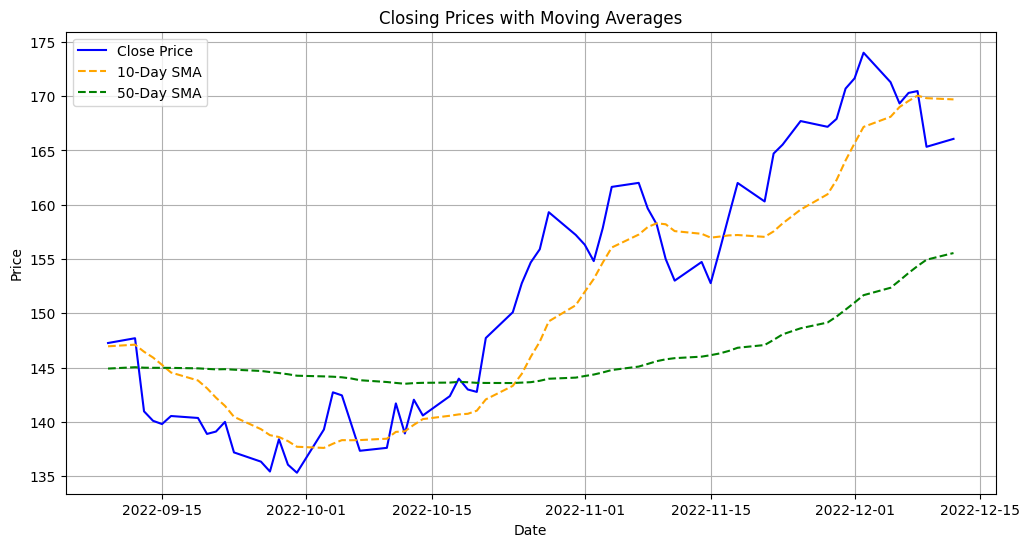

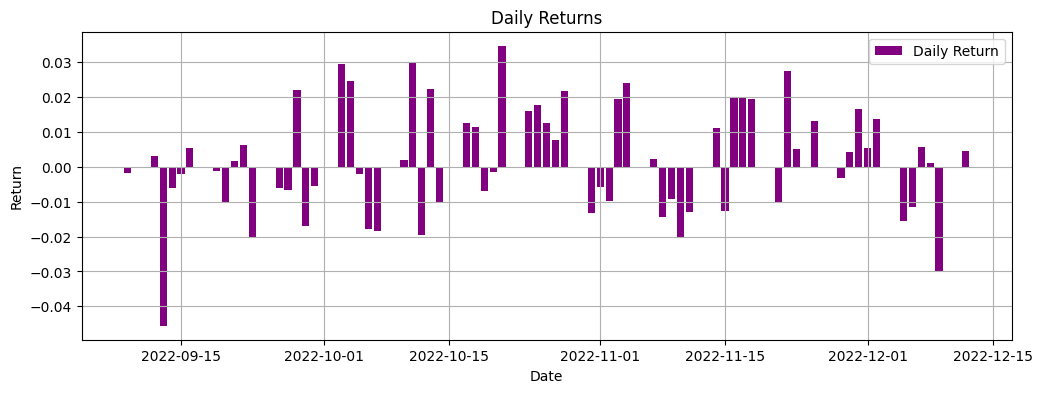

In [3]:
import matplotlib.pyplot as plt

# Plot Closing Prices and Moving Averages
plt.figure(figsize=(12, 6))
plt.plot(df_filtered['Date'], df_filtered['Close'], label='Close Price', color='blue')
plt.plot(df_filtered['Date'], df_filtered['SMA_10'], label='10-Day SMA', color='orange', linestyle='--')
plt.plot(df_filtered['Date'], df_filtered['SMA_50'], label='50-Day SMA', color='green', linestyle='--')
plt.title('Closing Prices with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

# Plot Daily Returns
plt.figure(figsize=(12, 4))
plt.bar(df_filtered['Date'], df_filtered['Daily_Return'], label='Daily Return', color='purple')
plt.title('Daily Returns')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid()
plt.show()

In [4]:
!pip install finrl
!pip install stable-baselines3
!pip install alpaca-trade-api
!pip install exchange-calendars
!pip install stockstats
!pip install wrds
!pip install git+https://github.com/AI4Finance-LLC/FinRL-Library.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.2/127.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu

In [5]:
# Import FinRL and necessary libraries
import finrl
#from finrl import config, config_tickers # config_tickers is deprecated. If you need to access specific ticker lists, you'll need to refer to the FinRL documentation.
from finrl import config
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv # The name of the submodule is StockTradingEnv (changed from env_stock_trading)
from finrl.agents.stablebaselines3.models import DRLAgent
from stable_baselines3 import DDPG

# Prepare data for FinRL
df_filtered.rename(columns={'Date': 'date', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close', 'Volume': 'volume'}, inplace=True)
df_filtered = df_filtered[['date', 'open', 'high', 'low', 'close', 'volume']]

# Add a 'tic' column (ticker symbol)
df_filtered['tic'] = 'SP500'

# Sort by date
df_filtered = df_filtered.sort_values(by='date')

print("\nDataFrame prepared for FinRL:")
print(df_filtered.head())


DataFrame prepared for FinRL:
           date        open        high         low       close   volume  \
6907 2022-09-09  147.539993  148.020004  146.630005  147.270004   854700   
6908 2022-09-12  148.059998  149.509995  147.149994  147.710007   825300   
6909 2022-09-13  146.339996  146.619995  140.389999  140.979996  1274400   
6910 2022-09-14  140.960007  141.869995  139.029999  140.110001  1072000   
6911 2022-09-15  140.899994  140.929993  139.369995  139.809998  1103900   

        tic  
6907  SP500  
6908  SP500  
6909  SP500  
6910  SP500  
6911  SP500  


DDPG Model Building

In [6]:
import gym
import numpy as np
import pandas as pd
from gym import spaces
from stable_baselines3 import DDPG
from stable_baselines3.common.noise import NormalActionNoise, OrnsteinUhlenbeckActionNoise

# Create a Custom Trading Environment for DDPG
class CustomTradingEnv(gym.Env):
    def __init__(self, df):
        super(CustomTradingEnv, self).__init__()

        self.df = df
        self.current_step = 0
        self.initial_balance = 10000  # Starting cash
        self.cash = self.initial_balance
        self.shares_held = 0
        self.max_steps = len(df) - 1

        # Action space: Continuous action between -1 and 1
        # -1: Sell all shares
        # 0: Hold
        # 1: Buy with all available cash
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)

        # Observation space: [Current Price, Moving Average, RSI, Cash Available, Shares Held]
        self.observation_space = spaces.Box(
            low=0, high=np.inf, shape=(5,), dtype=np.float32
        )

    def reset(self):
        self.current_step = 0
        self.cash = self.initial_balance
        self.shares_held = 0
        return self._next_observation()

    def _next_observation(self):
        obs = np.array([
            self.df.iloc[self.current_step]["Close"],
            self.df.iloc[self.current_step]["SMA_50"],
            self.df.iloc[self.current_step]["RSI"],
            self.cash,
            self.shares_held
        ], dtype=np.float32)
        return obs

    def step(self, action):
        current_price = self.df.iloc[self.current_step]["Close"]
        action = action[0]  # Extract the scalar value from the action array

        # Buy/Sell based on the continuous action
        if action > 0:  # Buy
            max_shares_to_buy = self.cash // current_price
            shares_to_buy = int(action * max_shares_to_buy)
            self.shares_held += shares_to_buy
            self.cash -= shares_to_buy * current_price
        elif action < 0:  # Sell
            shares_to_sell = int(-action * self.shares_held)
            self.shares_held -= shares_to_sell
            self.cash += shares_to_sell * current_price

        self.current_step += 1

        done = self.current_step >= self.max_steps
        reward = self.cash + (self.shares_held * current_price) - self.initial_balance

        return self._next_observation(), reward, done, {}

In [7]:
data = {
    'Close': np.random.rand(100) * 100,  # Random closing prices
    'SMA_50': np.random.rand(100) * 100,  # Random 50-day moving averages
    'RSI': np.random.rand(100) * 100      # Random RSI values
}
df = pd.DataFrame(data)

In [8]:
env = CustomTradingEnv(df)

In [9]:
!pip install shimmy>=2.0

In [10]:
# Define action noise for exploration
n_actions = env.action_space.shape[0]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))

# Initialize the DDPG model
model = DDPG(
    "MlpPolicy",
    env,
    verbose=1,
    action_noise=action_noise,
    tensorboard_log="./ddpg_trading_tensorboard/"
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Model Training

In [11]:
# Train the model
model.learn(total_timesteps=10000, log_interval=10)

# Save the model
model.save("ddpg_trading_model")

Logging to ./ddpg_trading_tensorboard/DDPG_1
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 99        |
|    ep_rew_mean     | 6.19e+13  |
| time/              |           |
|    episodes        | 10        |
|    fps             | 57        |
|    time_elapsed    | 17        |
|    total_timesteps | 990       |
| train/             |           |
|    actor_loss      | -1.35e+10 |
|    critic_loss     | 2.25e+25  |
|    learning_rate   | 0.001     |
|    n_updates       | 889       |
----------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 99        |
|    ep_rew_mean     | 3.1e+13   |
| time/              |           |
|    episodes        | 20        |
|    fps             | 58        |
|    time_elapsed    | 33        |
|    total_timesteps | 1980      |
| train/             |           |
|    actor_loss      | -5.51e+09 |
|    critic_loss     | 8.21e+24  |
|    learn

In [18]:
# Load the model if not already loaded
from stable_baselines3 import DDPG

model_path = "ddpg_trading_model.zip"
model = DDPG.load(model_path)

# Reset the environment
obs = env.reset()
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)  # Use deterministic actions for evaluation
    obs, reward, done, info = env.step(action)

# Calculate final portfolio value
if hasattr(env, "get_portfolio_value"):
    final_portfolio_value = env.get_portfolio_value()
else:
    final_cash = env.cash if hasattr(env, "cash") else info.get("final_cash", 0)
    final_shares_held = env.shares_held if hasattr(env, "shares_held") else info.get("final_shares_held", 0)
    final_stock_price = df.iloc[-1]["Close"]  # Ensure df is the correct dataset
    final_portfolio_value = final_cash + (final_shares_held * final_stock_price)

print("Final Portfolio Value:", final_portfolio_value)


Final Portfolio Value: 19228.75612216636


Calculation of Sharpe Ratio

In [16]:
# Replace with the following to directly use the trained model for prediction:
obs = env.reset()
account_value = env.initial_balance  # Initialize account value
df_account_value = []
df_actions = []

# Create a date range for the backtest
dates = pd.date_range(start='2023-01-01', periods=len(env.df), freq='D')  # Replace with your desired start date and frequency

for i in range(len(env.df)):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)
    account_value += reward

    # Use the generated date range instead of env.df['date']
    df_account_value.append([dates[i], account_value])  # Record date and account value
    df_actions.append([dates[i], action[0]])           # Record date and action

    if done:
        break

df_account_value = pd.DataFrame(df_account_value, columns=['date', 'account_value'])
df_actions = pd.DataFrame(df_actions, columns=['date', 'action'])


# Calculate key metrics
from finrl import config
from finrl.meta.preprocessor.preprocessors import data_split
from finrl.meta.data_processor import DataProcessor

# Calculate Sharpe Ratio
sharpe_ratio = (df_account_value['account_value'].pct_change().mean() / df_account_value['account_value'].pct_change().std()) * np.sqrt(252)

# Calculate Drawdown
df_account_value['peak'] = df_account_value['account_value'].cummax()
df_account_value['drawdown'] = (df_account_value['account_value'] - df_account_value['peak']) / df_account_value['peak']
max_drawdown = df_account_value['drawdown'].min()

print(f"Sharpe Ratio: {sharpe_ratio}")
print(f"Max Drawdown: {max_drawdown}")

Sharpe Ratio: -0.7661678960191982
Max Drawdown: -2.7006102060881787


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Hyperparameters Adjusting

In [22]:
# Define action noise for exploration
n_actions = env.action_space.shape[0]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))

# Initialize the DDPG model with adjusted hyperparameters
model = DDPG(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=1e-4,  # Reduced learning rate
    buffer_size=100000,
    batch_size=128,
    gamma=0.99,
    tau=0.005,
    action_noise=action_noise,
    tensorboard_log="./ddpg_trading_tensorboard/",
    # Remove max_grad_norm as it's not a direct parameter in DDPG
    # Gradient clipping might be handled internally or through a different mechanism
)

# Train the model
model.learn(total_timesteps=10000, log_interval=10)

# Save the model
model.save("ddpg_trading_model")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to ./ddpg_trading_tensorboard/DDPG_3


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 99        |
|    ep_rew_mean     | 6.12e+07  |
| time/              |           |
|    episodes        | 10        |
|    fps             | 104       |
|    time_elapsed    | 9         |
|    total_timesteps | 990       |
| train/             |           |
|    actor_loss      | -7.03e+05 |
|    critic_loss     | 2.02e+13  |
|    learning_rate   | 0.0001    |
|    n_updates       | 889       |
----------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 99        |
|    ep_rew_mean     | 3.06e+07  |
| time/              |           |
|    episodes        | 20        |
|    fps             | 96        |
|    time_elapsed    | 20        |
|    total_timesteps | 1980      |
| train/             |           |
|    actor_loss      | -1.03e+06 |
|    critic_loss     | 3.16e+12  |
|    learning_rate   | 0.0001    |
|    n_updates      

In [24]:
def calculate_drawdown(portfolio_values):
    peak = np.maximum.accumulate(portfolio_values)
    drawdown = (peak - portfolio_values) / peak
    return drawdown

In [28]:
def step(self, action):
    action = np.clip(action, -1, 1)  # Clip actions
    current_price = self.df.iloc[self.current_step]["Close"]

    # Calculate the portfolio value before taking the action
    prev_portfolio_value = self.cash + (self.shares_held * current_price)

    # Execute the action
    if action > 0:  # Buy
        max_shares_to_buy = self.cash // current_price
        shares_to_buy = int(action * max_shares_to_buy)
        self.shares_held += shares_to_buy
        self.cash -= shares_to_buy * current_price
    elif action < 0:  # Sell
        shares_to_sell = int(-action * self.shares_held)
        self.shares_held -= shares_to_sell
        self.cash += shares_to_sell * current_price

    self.current_step += 1

    # Calculate the new portfolio value
    new_portfolio_value = self.cash + (self.shares_held * current_price)

    # Calculate the reward as the change in portfolio value
    reward = new_portfolio_value - prev_portfolio_value

    # Penalize holding for too long
    if action == 0:  # Hold
        reward -= 10  # Small penalty for holding

    done = self.current_step >= self.max_steps

    return self._next_observation(), reward, done, {}

In [29]:
def _next_observation(self):
    obs = np.array([
        self.df.iloc[self.current_step]["Close"],
        self.df.iloc[self.current_step]["SMA_50"],
        self.df.iloc[self.current_step]["RSI"],
        self.cash / self.initial_balance,  # Normalize cash
        self.shares_held  # Number of shares held
    ], dtype=np.float32)
    return obs

In [30]:
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise

# Define action noise for exploration
n_actions = env.action_space.shape[0]
action_noise = OrnsteinUhlenbeckActionNoise(mean=np.zeros(n_actions), sigma=0.2 * np.ones(n_actions))

In [31]:
# Train the model
model.learn(total_timesteps=50000, log_interval=10)

Logging to ./ddpg_trading_tensorboard/DDPG_4
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 99        |
|    ep_rew_mean     | 3.47e+06  |
| time/              |           |
|    episodes        | 10        |
|    fps             | 96        |
|    time_elapsed    | 10        |
|    total_timesteps | 990       |
| train/             |           |
|    actor_loss      | -2.47e+05 |
|    critic_loss     | 5.69e+09  |
|    learning_rate   | 0.0001    |
|    n_updates       | 10789     |
----------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 99        |
|    ep_rew_mean     | 1.73e+06  |
| time/              |           |
|    episodes        | 20        |
|    fps             | 93        |
|    time_elapsed    | 21        |
|    total_timesteps | 1980      |
| train/             |           |
|    actor_loss      | -2.92e+05 |
|    critic_loss     | 8.96e+09  |
|    learn

In [ ]:
!tensorboard --logdir=./ddpg_trading_tensorboard/

2025-02-16 05:27:57.262909: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739683677.317910    9941 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739683677.335477    9941 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-16 05:28:02.442969: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

Serving TensorBoard on localhost; to expose to the network, u